In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# load birth data
df = pd.read_csv('https://raw.githubusercontent.com/fivethirtyeight/data/master/births/US_births_2000-2014_SSA.csv')


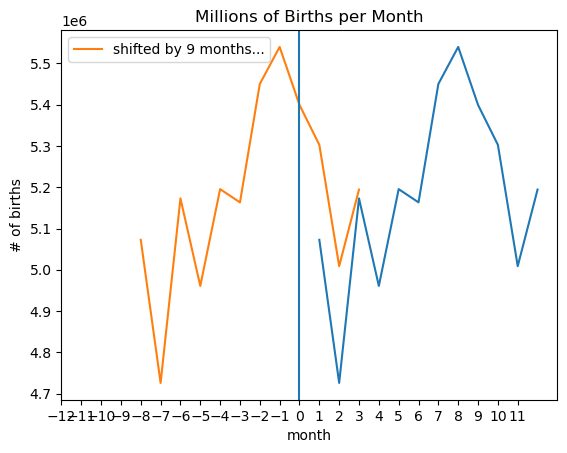

In [12]:
month_grp = df.groupby('month')
births_by_month = month_grp.sum()

plt.plot(births_by_month.index, births_by_month.births)
plt.plot(births_by_month.index - 9, births_by_month.births, label='shifted by 9 months...')
plt.title('Millions of Births per Month')
plt.ylabel('# of births')
plt.xlabel('month')
plt.xticks(np.arange(-12, 12, step=1))
plt.axvline(0)
plt.legend()

In [13]:
df

,year,month,date_of_month,day_of_week,births
0,2000,1,1,6,9083
1,2000,1,2,7,8006
2,2000,1,3,1,11363
3,2000,1,4,2,13032
4,2000,1,5,3,12558
...,...,...,...,...,...
5474,2014,12,27,6,8656
5475,2014,12,28,7,7724
5476,2014,12,29,1,12811
5477,2014,12,30,2,13634


In [14]:
df['date'] = pd.to_datetime(df[['year', 'month']].assign(day=1))
df

,year,month,date_of_month,day_of_week,births,date
0,2000,1,1,6,9083,2000-01-01
1,2000,1,2,7,8006,2000-01-01
2,2000,1,3,1,11363,2000-01-01
3,2000,1,4,2,13032,2000-01-01
4,2000,1,5,3,12558,2000-01-01
...,...,...,...,...,...,...
5474,2014,12,27,6,8656,2014-12-01
5475,2014,12,28,7,7724,2014-12-01
5476,2014,12,29,1,12811,2014-12-01
5477,2014,12,30,2,13634,2014-12-01


In [21]:
df_shifted = df.copy()
df_shifted['date'] = df_shifted['date'] - pd.DateOffset(months=9)
df_shifted['month'] = df_shifted['date'].dt.month
df_shifted['date_of_month'] = df_shifted['date'].dt.day
df_shifted['day_of_week'] = df_shifted['date'].dt.day_of_week
df_shifted

,year,month,date_of_month,day_of_week,births,date
0,2000,4,1,3,9083,1999-04-01
1,2000,4,1,3,8006,1999-04-01
2,2000,4,1,3,11363,1999-04-01
3,2000,4,1,3,13032,1999-04-01
4,2000,4,1,3,12558,1999-04-01
...,...,...,...,...,...,...
5474,2014,3,1,5,8656,2014-03-01
5475,2014,3,1,5,7724,2014-03-01
5476,2014,3,1,5,12811,2014-03-01
5477,2014,3,1,5,13634,2014-03-01


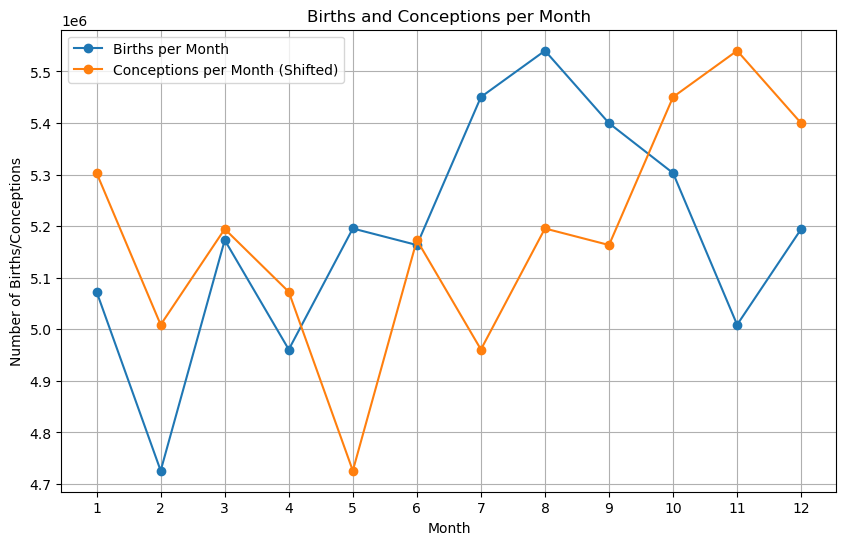

In [65]:
monthly_birth = df.groupby('month')
births_per_month = monthly_birth['births'].sum()

monthly_concep = df_shifted.groupby('month')
concep_per_month = monthly_concep['births'].sum()


plt.figure(figsize=(10, 6))
plt.plot(births_per_month.index, births_per_month, label='Births per Month', marker='o')
plt.plot(concep_per_month.index, concep_per_month, label='Conceptions per Month (Shifted)', marker='o')
plt.title('Births and Conceptions per Month')
plt.xlabel('Month')
plt.ylabel('Number of Births/Conceptions')
plt.xticks(np.arange(1, 13, step=1))
plt.legend()
plt.grid(True)
plt.show()

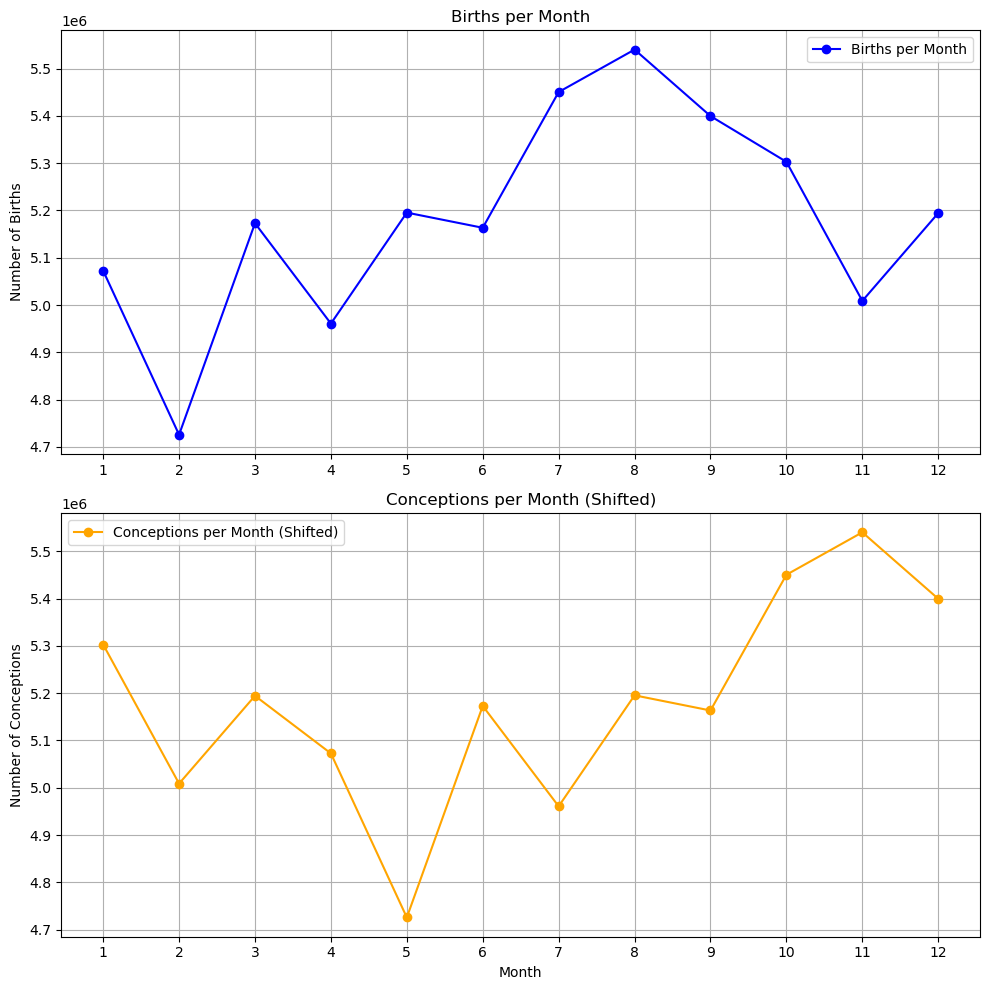

In [66]:
fig, axes = plt.subplots(2, 1, figsize=(10, 10))

# births per month
axes[0].plot(births_per_month.index, births_per_month, label='Births per Month', marker='o', color='blue')
axes[0].set_title('Births per Month')
axes[0].set_ylabel('Number of Births')
axes[0].grid(True)
axes[0].set_xticks(np.arange(1, 13, step=1))
axes[0].legend()

# conceptions per month (shifted by 9 months)
axes[1].plot(concep_per_month.index, concep_per_month, label='Conceptions per Month (Shifted)', marker='o', color='orange')
axes[1].set_title('Conceptions per Month (Shifted)')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Number of Conceptions')
axes[1].grid(True)
axes[1].set_xticks(np.arange(1, 13, step=1))
axes[1].legend()
plt.tight_layout()
plt.show()


In [38]:
sales_df = pd.read_csv('../data/retail_sales_dataset.csv')
# Rename the 'Date' column to 'date'
sales_df.rename(columns={'Date': 'date'}, inplace=True)
sales_df['date'] = pd.to_datetime(sales_df['date'])
sales_df['month'] = sales_df['date'].dt.month
sales_df

,Transaction ID,date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,month
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,11
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,2
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,1
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,5
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,5
...,...,...,...,...,...,...,...,...,...,...
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50,5
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90,11
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100,10
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150,12


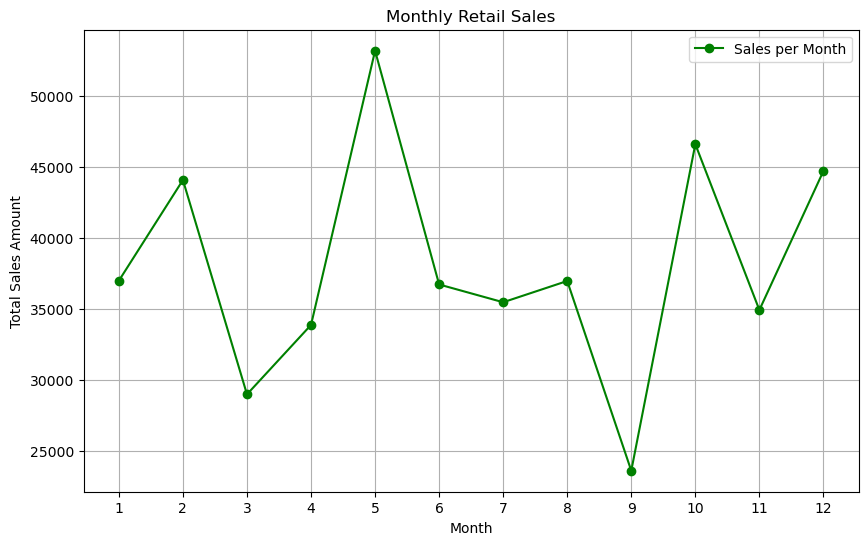

In [67]:
monthly_sales = sales_df.groupby('month')
sales_per_month = monthly_sales['Total Amount'].sum()
plt.figure(figsize=(10, 6))
plt.plot(sales_per_month.index, sales_per_month, label='Sales per Month', marker='o', color='green')
plt.title('Monthly Retail Sales')
plt.xlabel('Month')
plt.ylabel('Total Sales Amount')
plt.xticks(np.arange(1, 13, step=1))
plt.grid(True)
plt.legend()
plt.show()

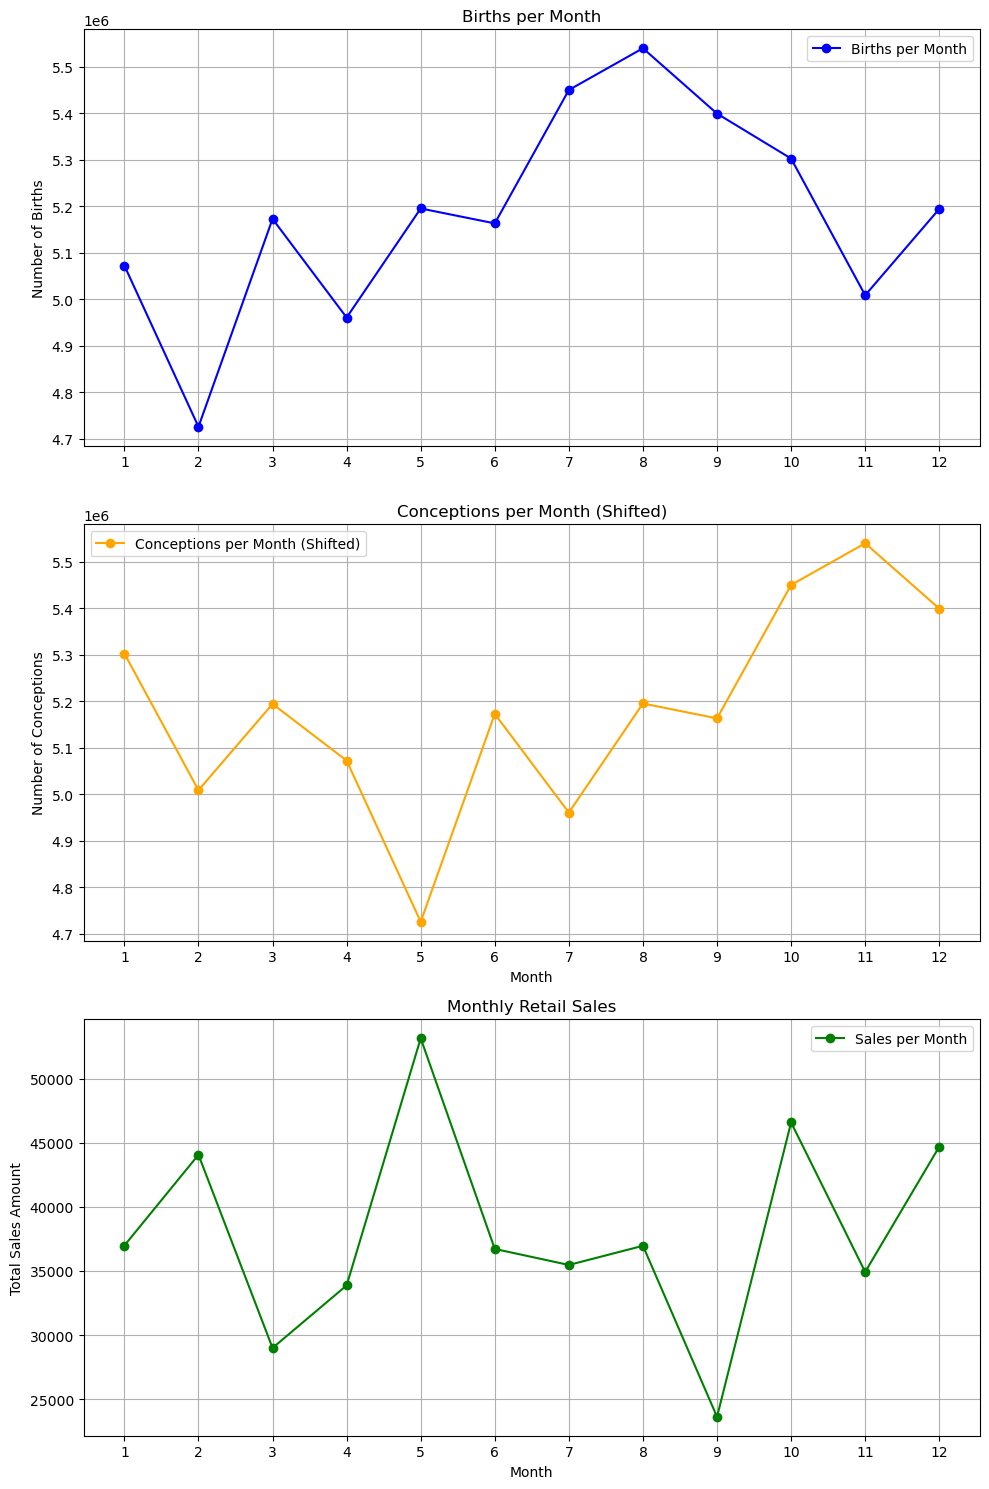

In [68]:
# Create subplots for births, conceptions, and sales per month
fig, axes = plt.subplots(3, 1, figsize=(10, 15))  # Removed sharex=True

# births per month
axes[0].plot(births_per_month.index, births_per_month, label='Births per Month', marker='o', color='blue')
axes[0].set_title('Births per Month')
axes[0].set_ylabel('Number of Births')
axes[0].grid(True)
axes[0].set_xticks(np.arange(1, 13, step=1))
axes[0].legend()

# conceptions per month (shifted by 9 months)
axes[1].plot(concep_per_month.index, concep_per_month, label='Conceptions per Month (Shifted)', marker='o', color='orange')
axes[1].set_title('Conceptions per Month (Shifted)')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Number of Conceptions')
axes[1].grid(True)
axes[1].set_xticks(np.arange(1, 13, step=1))
axes[1].legend()

# sales per month
axes[2].plot(sales_per_month.index, sales_per_month, label='Sales per Month', marker='o', color='green')
axes[2].set_title('Monthly Retail Sales')
axes[2].set_xlabel('Month')
axes[2].set_ylabel('Total Sales Amount')
axes[2].grid(True)
axes[2].legend()
axes[2].set_xticks(np.arange(1, 13, step=1)) 
plt.tight_layout()
plt.show()

In [51]:
credits_df = pd.read_csv('../data/TMDB_movie_dataset/tmdb_5000_credits.csv')
movies_df = pd.read_csv('../data/TMDB_movie_dataset/tmdb_5000_movies.csv')

print(f'Credits Columns: {list(credits_df.columns)} \nMovies Columns: {list(movies_df.columns)}')

Credits Columns: ['movie_id', 'title', 'cast', 'crew'] 
Movies Columns: ['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language', 'original_title', 'overview', 'popularity', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'vote_average', 'vote_count']


### Lets start with the obvious...Rating to Budget

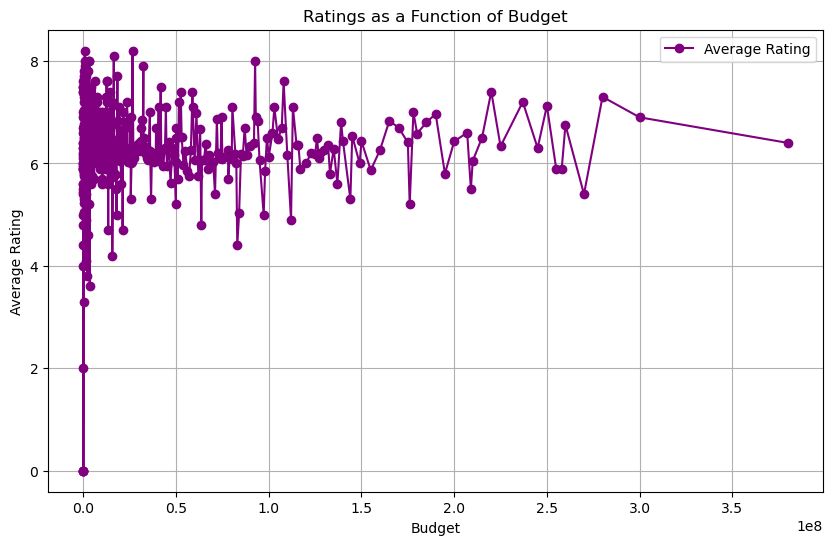

In [55]:
budget_grp = movies_df.groupby('budget')
budget_to_ratings = budget_grp['vote_average'].mean()

plt.figure(figsize=(10, 6))
plt.plot(ratings_by_budget.index, ratings_by_budget, marker='o', color='purple', label='Average Rating')
plt.title('Ratings as a Function of Budget')
plt.xlabel('Budget')
plt.ylabel('Average Rating')
plt.grid(True)
plt.legend()
plt.show()

#### it seems budget has nothing to do with average rating. No suprise there. Do ratings and revenu overlap tho?

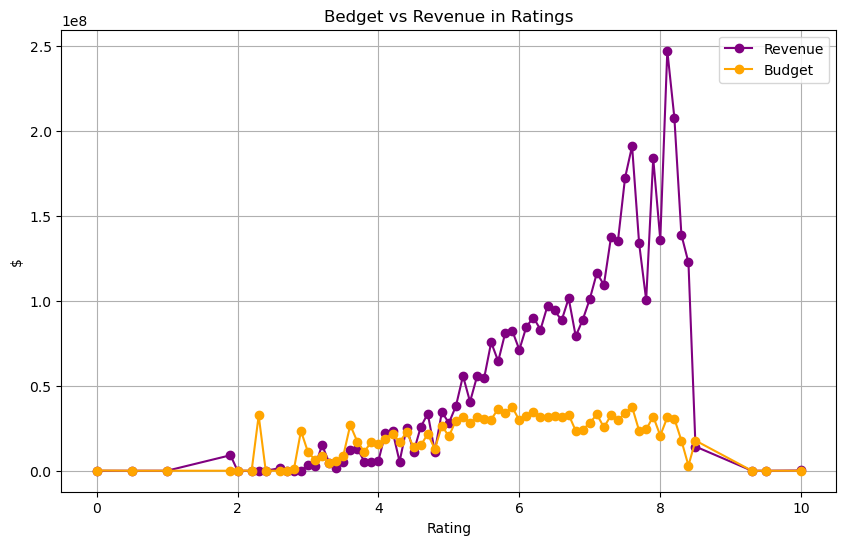

In [62]:
ratings_grp = movies_df.groupby('vote_average')
revenue_to_ratings = ratings_grp['revenue'].mean()
budget_to_ratings = ratings_grp['budget'].mean()

plt.figure(figsize=(10, 6))
plt.plot(revenue_to_ratings.index, revenue_to_ratings, marker='o', color='purple', label='Revenue')
plt.plot(budget_to_ratings.index, budget_to_ratings, marker='o', color='orange', label='Budget')
plt.title('Bedget vs Revenue in Ratings')
plt.xlabel('Rating')
plt.ylabel('$')
plt.grid(True)
plt.legend()
plt.show()


#### Bad news for Hollywood execs everywhere: you can't just spend more money and make a good product. 
Though, it seems no one is trying that. Almost as if they understand a movie wont get better if you spend more than half a billion dollars on it. That really seems to be the cap.